# Calculating hosting capacity for SDG&E
Use the hosting capacity calculation methodology from Brockway et al (2021) to calculate the hosting capacity for SDG&E at the census tract level. 

In [43]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import MultiLineString
import matplotlib.pyplot as plt

### Load in data

In [44]:
# read in feederline data
sdge_feederlines = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sandiego_grid/gen_cap_lines_sdge.geojson")

# read in multifamily data
sdge_multifamily = gpd.read_file("../../../../capstone/electrigrid/data/building_zillow_merges/sdcounty_buildings/multi_summed_units_sd.geojson")

# read in the single family data  
sdge_singlefamily = gpd.read_file("../../../../capstone/electrigrid/data/building_zillow_merges/sdcounty_buildings/sdge_singlefamily.geojson")

# read in the census tract data
census_tracts = gpd.read_file("../../../../capstone/electrigrid/data/census/tl_2025_06_tract/tl_2025_06_tract.shp")

# load in shapefile for extent of SDGE
utility_ter = gpd.read_file("../../../../capstone/electrigrid/data/utilities/IOU_shapefiles.geojson")

In [45]:
# view feederline data
sdge_feederlines.head()

,LINE_SEGMENT_NUMBER,CIRCUIT_NAME,SUBID,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,OBJECTID,VOLTAGE,ICAWOF_PVGENERATION,OHUG,LABELTEXT,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,geometry
0,1,221,SANTA YSABEL,0.0,0.2,0.0,0.2,32929650,12,0.1,OH,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-116.43681 32.97732, -116.43681 32..."
1,21,211,WARNERS,0.0,0.0,0.0,0.0,32789112,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (-116.52521 33.22100, -116.52521 33..."
2,22,211,WARNERS,0.0,0.0,0.0,0.0,32783141,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (-116.52522 33.21894, -116.52522 33..."
3,24,211,WARNERS,0.0,0.0,0.0,0.0,32784298,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (-116.53426 33.21107, -116.53426 33..."
4,25,211,WARNERS,0.0,0.0,0.0,0.0,32784301,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (-116.53751 33.21427, -116.53730 33..."


# Clip the census tract data to SDG&E 

In [46]:
# view the utility data frame
utility_ter.head()

,OBJECTID,Acronym,Utility,AgencyNum,Type,URL,Phone,Address,HIFLD_ID,Sales_GWh_1990,...,Sales_GWh_2019,Sales_GWh_2020,Sales_GWh_2021,Sales_GWh_2022,Sales_GWh_2023,Sales_GWh_2024,Sales_GWh_2025,OnlineName,Audit,geometry
0,1,,PacifiCorp,71026.0,IOU,https://www.pacificorp.com/,(503) 813-5000,"825 NE Multnomah Street, Suite 2000 Portland, ...",14354,736.955156,...,742.775668,762.225388,794.358238,801.710660,774.312862,None,None,None,None,"MULTIPOLYGON Z (((-124.20211 41.74485 0.00000,..."
1,2,,Liberty Utilities,84372.0,IOU,http://www.libertyutilities.com/west/?region=C...,800.782.2506,"933 Eloise Ave South Lake Tahoe, CA 96150",57483,426.373385,...,564.199718,553.802343,559.771745,558.609575,539.033661,None,None,None,None,"POLYGON Z ((-120.08497 39.70865 0.00000, -120...."
2,3,SCE,Southern California Edison,86250.0,IOU,https://www.sce.com/,(818) 302-1212,"2244 Walnut Grove Avenue Rosemead, CA 91770-3714",17609,71016.547845,...,81183.999994,81054.000005,81132.999996,82971.000004,76840.077169,None,None,None,None,"MULTIPOLYGON Z (((-118.60361 33.47801 0.00000,..."
3,4,PG&E,Pacific Gas & Electric Company,71021.0,IOU,https://www.pge.com/,(415) 973-7000,"77 Beale Street San Francisco, CA 94105",14328,70036.326445,...,78389.925613,78518.835139,78438.000003,77887.000005,72932.833237,None,None,None,None,"MULTIPOLYGON Z (((-120.87195 35.21664 0.00000,..."
4,5,SDG&E,San Diego Gas & Electric,80402.0,IOU,https://www.sdge.com/,(619) 696-2000,"P.O. Box 129831 San Diego, CA 92112-9831",16609,14396.900280,...,17681.971922,17444.765817,17444.765817,17867.262050,16982.218070,None,None,None,None,"MULTIPOLYGON Z (((-117.12961 32.62193 0.00000,..."


In [47]:
# filter to only sdge 
shape_sdge = utility_ter[utility_ter['Acronym'] == 'SDG&E'] 

# check the crs
shape_sdge = shape_sdge.to_crs('EPSG:3310')

In [48]:
census_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,065,042516,06065042516,1400000US06065042516,425.16,Census Tract 425.16,G5020,S,973130,0,+33.9227363,-117.2393879,"POLYGON ((-117.24375 33.92818, -117.24323 33.9..."
1,06,065,042716,06065042716,1400000US06065042716,427.16,Census Tract 427.16,G5020,S,2698784,711913,+33.6865062,-117.2551285,"POLYGON ((-117.27209 33.68473, -117.27117 33.6..."
2,06,065,042717,06065042717,1400000US06065042717,427.17,Census Tract 427.17,G5020,S,6425166,145210,+33.6997108,-117.2534257,"POLYGON ((-117.26908 33.70438, -117.26882 33.7..."
3,06,065,042902,06065042902,1400000US06065042902,429.02,Census Tract 429.02,G5020,S,43393952,0,+33.7493422,-117.3068291,"POLYGON ((-117.34733 33.78247, -117.34731 33.7..."
4,06,065,042903,06065042903,1400000US06065042903,429.03,Census Tract 429.03,G5020,S,44642454,0,+33.8027798,-117.3133054,"POLYGON ((-117.36332 33.82940, -117.36331 33.8..."


In [49]:
# change the crs of the census tract data
census_tracts = census_tracts.to_crs('EPSG:3310')

# add a check before performing geospatial clipping
assert census_tracts.crs == shape_sdge.crs

# mask the census tract to the sdge area
census_tracts = census_tracts.clip(shape_sdge)


# Calculate hosting capacity for only one census/polygon combo as an example
The hosting capacity calculation is complex. To ensure we understand the step by step process we'll work on just one circuit polygon combo. Then we can create a for loop to iterate the analysis over all of the census tracts and feederlines.


#### Step 1: Link the homes to the nearest feederline

Each home gets its electricty from a specific feederline. The nearest neighbor is the method chosen. Then to avoid including homes that are outliers and likely gettin electricity from other sources homes that are further than 1km from their assigned feederline are dropped. 

In [50]:

# change the crs to a projected CRS
sdge_feederlines = sdge_feederlines.to_crs("EPSG:3310")
sdge_singlefamily = sdge_singlefamily.to_crs("EPSG:3310")

# add a check for crs matching
assert sdge_feederlines.crs == sdge_singlefamily.crs


# index the data
sdge_feederlines.sindex
sdge_singlefamily.sindex

# spatial join
sdge_singlefamily_linked = gpd.sjoin_nearest(sdge_singlefamily, 
                                        sdge_feederlines, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

# crop homes that are further than 1km from their assigned feederline
sdge_singlefamily_linked = sdge_singlefamily_linked[sdge_singlefamily_linked['dist_to_line_m'] < 1000] 

In [51]:
# change the crs to a projected CRS
sdge_multifamily = sdge_multifamily.to_crs("EPSG:3310")

# add a check for crs matching
assert sdge_feederlines.crs == sdge_multifamily.crs

# index the data
sdge_feederlines.sindex
sdge_multifamily.sindex

# spatial join
sdge_multifamily_linked = gpd.sjoin_nearest(sdge_multifamily, 
                                        sdge_feederlines, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

# crop homes that are further than 1km from their assigned feederline
sdge_multifamily_linked = sdge_multifamily_linked[sdge_multifamily_linked['dist_to_line_m'] < 1000] 

#### Step 1a: Create line length column

Our data analysis will need length data for each line segment. This value is provided in the SCE data but must be calculated for the SDG&E data. Let's calculate the lengths for each segment of the feederline.

In [52]:
# create length column in metres
sdge_feederlines['LENGTH(M)'] = sdge_feederlines.length

In [53]:
sdge_feederlines.head()

,LINE_SEGMENT_NUMBER,CIRCUIT_NAME,SUBID,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,OBJECTID,VOLTAGE,ICAWOF_PVGENERATION,OHUG,LABELTEXT,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,geometry,LENGTH(M)
0,1,221,SANTA YSABEL,0.0,0.2,0.0,0.2,32929650,12,0.1,OH,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (333366.451 -553270.699, 333365.749...",22.554269
1,21,211,WARNERS,0.0,0.0,0.0,0.0,32789112,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (324110.570 -526595.605, 324109.876...",22.259666
2,22,211,WARNERS,0.0,0.0,0.0,0.0,32783141,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (324117.905 -526823.988, 324117.212...",22.262382
3,24,211,WARNERS,0.0,0.0,0.0,0.0,32784298,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (323307.246 -527726.400, 323306.552...",22.271703
4,25,211,WARNERS,0.0,0.0,0.0,0.0,32784301,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (322990.866 -527382.568, 323007.531...",78.631643


#### Step 2: Add census tract ID (TRACTCE) to each home through spatial join

These tract IDs should be added to the homes dataframes as they are necessary for further calculations. 


In [54]:
# view the attributes of the census tract dataframe
census_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
4503,06,073,010009,06073010009,1400000US06073010009,100.09,Census Tract 100.09,G5020,S,4035019,302,+32.5473763,-117.0528794,"POLYGON Z ((275529.078 -603346.514 0.000, 2755..."
118,06,073,010109,06073010109,1400000US06073010109,101.09,Census Tract 101.09,G5020,S,12019277,904239,+32.5498297,-117.0906305,"POLYGON Z ((271048.417 -603899.989 0.000, 2710..."
4505,06,073,010013,06073010013,1400000US06073010013,100.13,Census Tract 100.13,G5020,S,896530,0,+32.5555376,-117.0474702,"POLYGON Z ((277107.189 -601286.509 0.000, 2771..."
7105,06,073,010012,06073010012,1400000US06073010012,100.12,Census Tract 100.12,G5020,S,629589,0,+32.5607766,-117.0585027,"POLYGON Z ((276283.262 -601317.511 0.000, 2762..."
3149,06,073,010111,06073010111,1400000US06073010111,101.11,Census Tract 101.11,G5020,S,605556,0,+32.5642007,-117.0662929,"POLYGON Z ((275249.373 -600873.079 0.000, 2753..."


In [55]:
# make sure the dataframes have the same crs before performing spatial computations
assert census_tracts.crs == sdge_multifamily_linked.crs
assert census_tracts.crs == sdge_singlefamily_linked.crs

# assign each home to its census tracts
sdge_singlefamily_linked = gpd.sjoin(sdge_singlefamily_linked, census_tracts[['TRACTCE', 'geometry']], how = "left", predicate = "within")
sdge_multifamily_linked = gpd.sjoin(sdge_multifamily_linked, census_tracts[['TRACTCE', 'geometry']], how = "left", predicate = "within")

#### Step 3: Calculate the number of homes in each census tract

The number of homes in each census tract is used further in the calculation. Save it as a new column in the homes dataframes. 

In [56]:
sdge_singlefamily_linked['TOTAL_HOMES_PER_TRACT'] = sdge_singlefamily_linked.groupby('TRACTCE')['TRACTCE'].transform('count')
sdge_multifamily_linked['TOTAL_HOMES_PER_TRACT'] = sdge_multifamily_linked.groupby('TRACTCE')['TRACTCE'].transform('count')

#### Step 4: Calculate the maximum ICA generation capacity for each circuit

Generation capacity varies across the circuit. The maximum is utilized in calculating the hosting capacity. Add the new data to the data frame as a column.


In [57]:
# save the max ICA generation capacity by the circuit
sdge_singlefamily_linked['MAX_GEN_WOF_CIRCUIT'] = sdge_singlefamily_linked.groupby('CIRCUIT_NAME')['ICAWOF_UNIGENERATION'].transform('max')
sdge_singlefamily_linked['MAX_GEN_WNOF_CIRCUIT'] = sdge_singlefamily_linked.groupby('CIRCUIT_NAME')['ICAWNOF_UNIGENERATION'].transform('max')

sdge_multifamily_linked['MAX_GEN_WOF_CIRCUIT'] = sdge_multifamily_linked.groupby('CIRCUIT_NAME')['ICAWOF_UNIGENERATION'].transform('max')
sdge_multifamily_linked['MAX_GEN_WNOF_CIRCUIT'] = sdge_multifamily_linked.groupby('CIRCUIT_NAME')['ICAWNOF_UNIGENERATION'].transform('max')

#### Step 5: Calculate the percentage of the length of each segment relative to the entire feederline

First calculate the length of the whole circuit. Then divide each segment’s length by the length of the whole circuit. Save to the dataframe in a new column. 


In [58]:
# calculate the whole length of the circuit
sdge_circuit_lengths = sdge_feederlines.groupby('CIRCUIT_NAME').sum('LENGTH(M)')

# rename the column that has the total length
sdge_circuit_lengths.rename(columns = {'LENGTH(M)':'TOTAL_CIRCUIT_LENGTH(M)'}, inplace = True)

# join the circuit lengths to the original dataframe
sdge_feederlines_lengths = pd.merge(sdge_feederlines, sdge_circuit_lengths['TOTAL_CIRCUIT_LENGTH(M)'], on = 'CIRCUIT_NAME', how = 'left')

# calculate the percentage of the length of each segment relative to the whole dataframe
sdge_feederlines_lengths['PERCENT_LENGTH_OF_CIRCUIT'] = sdge_feederlines_lengths['LENGTH(M)']/sdge_feederlines_lengths['TOTAL_CIRCUIT_LENGTH(M)']

sdge_feederlines_lengths.head()

,LINE_SEGMENT_NUMBER,CIRCUIT_NAME,SUBID,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,OBJECTID,VOLTAGE,ICAWOF_PVGENERATION,...,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,geometry,LENGTH(M),TOTAL_CIRCUIT_LENGTH(M),PERCENT_LENGTH_OF_CIRCUIT
0,1,221,SANTA YSABEL,0.0,0.2,0.0,0.2,32929650,12,0.1,...,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (333366.451 -553270.699, 333365.749...",22.554269,115818.621825,0.000195
1,21,211,WARNERS,0.0,0.0,0.0,0.0,32789112,12,0.1,...,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (324110.570 -526595.605, 324109.876...",22.259666,54134.972711,0.000411
2,22,211,WARNERS,0.0,0.0,0.0,0.0,32783141,12,0.1,...,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (324117.905 -526823.988, 324117.212...",22.262382,54134.972711,0.000411
3,24,211,WARNERS,0.0,0.0,0.0,0.0,32784298,12,0.1,...,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (323307.246 -527726.400, 323306.552...",22.271703,54134.972711,0.000411
4,25,211,WARNERS,0.0,0.0,0.0,0.0,32784301,12,0.1,...,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (322990.866 -527382.568, 323007.531...",78.631643,54134.972711,0.001453


#### Step 6:  Calculate the number of homes connected to each segment



In [59]:
# aggregate number of homes that connect to each segment
sdge_singlefamily_linked ['TOTAL_HOMES_PER_SEGMENT'] = sdge_singlefamily_linked.groupby('LINE_SEGMENT_NUMBER')['LINE_SEGMENT_NUMBER'].transform('count')
sdge_multifamily_linked ['TOTAL_HOMES_PER_SEGMENT'] = sdge_multifamily_linked.groupby('LINE_SEGMENT_NUMBER')['LINE_SEGMENT_NUMBER'].transform('count')

#### Step 7:  Calculate the total number of homes connected to the whole circuit

In [60]:
# aggregate number of homes that connect to each circuit
sdge_singlefamily_linked ['TOTAL_HOMES_PER_CIRCUIT'] = sdge_singlefamily_linked.groupby('CIRCUIT_NAME')['CIRCUIT_NAME'].transform('count')
sdge_multifamily_linked ['TOTAL_HOMES_PER_CIRCUIT'] = sdge_multifamily_linked.groupby('CIRCUIT_NAME')['CIRCUIT_NAME'].transform('count')

#### Step 8:  Calculate the percent of homes connected to each segment relative to all of the homes connected to the entire circuit

In [61]:
sdge_singlefamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT'] = sdge_singlefamily_linked['TOTAL_HOMES_PER_SEGMENT'] / sdge_singlefamily_linked['TOTAL_HOMES_PER_CIRCUIT']
sdge_multifamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT'] = sdge_multifamily_linked['TOTAL_HOMES_PER_SEGMENT'] / sdge_multifamily_linked['TOTAL_HOMES_PER_CIRCUIT']

#### Step 9:  Calculate the weighted generation capacity for each segment of the feederline

Multiply the total generation capacity of the segment by the percent of homes connected to each segment. This calculation undercounts the total generation capacity.

In [62]:
# weighted generation capacity calculations single family homes
sdge_singlefamily_linked['WEIGHTED_GEN_CAPWOF'] = sdge_singlefamily_linked['ICAWOF_UNIGENERATION'] * sdge_singlefamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT']
sdge_singlefamily_linked['WEIGHTED_GEN_CAPWNOF'] = sdge_singlefamily_linked['ICAWNOF_UNIGENERATION'] * sdge_singlefamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT']

# weighted generation capacity calculations multi family homes
sdge_multifamily_linked['WEIGHTED_GEN_CAPWOF'] = sdge_multifamily_linked['ICAWOF_UNIGENERATION'] * sdge_multifamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT']
sdge_multifamily_linked['WEIGHTED_GEN_CAPWNOF'] = sdge_multifamily_linked['ICAWNOF_UNIGENERATION'] * sdge_multifamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT']

#### Step 10:  Calculate the number of homes located within each census tract for each circuit


In [63]:
sdge_singlefamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT'] = sdge_singlefamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['CIRCUIT_NAME'].transform('count')
sdge_multifamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT'] = sdge_multifamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['CIRCUIT_NAME'].transform('count')

#### Step 11:  Calculate the weighted household max hosting capacity for each circuit tract combo

Divide the number of homes located within each census tract for each circuit by the total number of homes connected to the whole circuit and multiply that value by the max generation capacity report for each circuit tract combo.


In [64]:
# calculate the max generation capacity for the circuit tract combo
sdge_singlefamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'] = sdge_singlefamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['ICAWOF_UNIGENERATION'].transform('max')
sdge_singlefamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'] = sdge_singlefamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['ICAWNOF_UNIGENERATION'].transform('max')

sdge_multifamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'] = sdge_multifamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['ICAWOF_UNIGENERATION'].transform('max')
sdge_multifamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'] = sdge_multifamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['ICAWNOF_UNIGENERATION'].transform('max')


In [65]:
# calculate the weighted household max hosting capacity for each circuit tract combo
sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT'] = (sdge_singlefamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']/ sdge_singlefamily_linked['TOTAL_HOMES_PER_CIRCUIT']) * sdge_singlefamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT']
sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT'] = (sdge_singlefamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']/ sdge_singlefamily_linked['TOTAL_HOMES_PER_CIRCUIT']) * sdge_singlefamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT']

sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT'] = (sdge_multifamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']/ sdge_multifamily_linked['TOTAL_HOMES_PER_CIRCUIT']) * sdge_multifamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT']
sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT'] = (sdge_multifamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']/ sdge_multifamily_linked['TOTAL_HOMES_PER_CIRCUIT']) * sdge_multifamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT']

####  Step 12:  Normalize the generation capacity for each circuit polygon combo

We normalize the generation capacity because weighting the generation capacity under counts the total number of MW available. 

Divide the maximum hosting capacity from anywhere on the given circuit by the  weighted household max hosting capacity for each circuit tract combo, and then multiply by the  weighted household max hosting capacity for each circuit tract combo. 



In [69]:
sdge_singlefamily_linked['NORMALIZED_GEN_WOF'] = (sdge_singlefamily_linked['MAX_GEN_WOF_CIRCUIT'] / sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT']) * sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT']
sdge_singlefamily_linked['NORMALIZED_GEN_WNOF'] = (sdge_singlefamily_linked['MAX_GEN_WNOF_CIRCUIT'] / sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT']) * sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT']

sdge_multifamily_linked['NORMALIZED_GEN_WOF'] = (sdge_multifamily_linked['MAX_GEN_WOF_CIRCUIT'] / sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT']) * sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT']
sdge_multifamily_linked['NORMALIZED_GEN_WNOF'] = (sdge_multifamily_linked['MAX_GEN_WNOF_CIRCUIT'] / sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT']) * sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT']

#### Step 13:  Adjust the normalized values to the maximum generation

For each normalized value for the circuit polygon combos, ensure they are not over the original maximum value for that circuit polygon. Adjust down to the max where necessary.


In [71]:
sdge_singlefamily_linked['ADJUSTED_NORM_GEN_WOF'] = np.where(sdge_singlefamily_linked['NORMALIZED_GEN_WOF'] > sdge_singlefamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'], sdge_singlefamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'], sdge_singlefamily_linked['NORMALIZED_GEN_WOF'])
sdge_singlefamily_linked['ADJUSTED_NORM_GEN_WNOF'] = np.where(sdge_singlefamily_linked['NORMALIZED_GEN_WNOF'] > sdge_singlefamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'], sdge_singlefamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'], sdge_singlefamily_linked['NORMALIZED_GEN_WNOF'])

sdge_multifamily_linked['ADJUSTED_NORM_GEN_WOF'] = np.where(sdge_multifamily_linked['NORMALIZED_GEN_WOF'] > sdge_multifamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'], sdge_multifamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'], sdge_multifamily_linked['NORMALIZED_GEN_WOF'])
sdge_multifamily_linked['ADJUSTED_NORM_GEN_WNOF'] = np.where(sdge_multifamily_linked['NORMALIZED_GEN_WNOF'] > sdge_multifamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'], sdge_multifamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'], sdge_multifamily_linked['NORMALIZED_GEN_WNOF'])

#### Step 14: Calculate the household hosting capacity

Divide the generation capacity for the circuit tracts by the number of homes connected in that circuit polygon.

# Map all of the data sources

KeyboardInterrupt: 

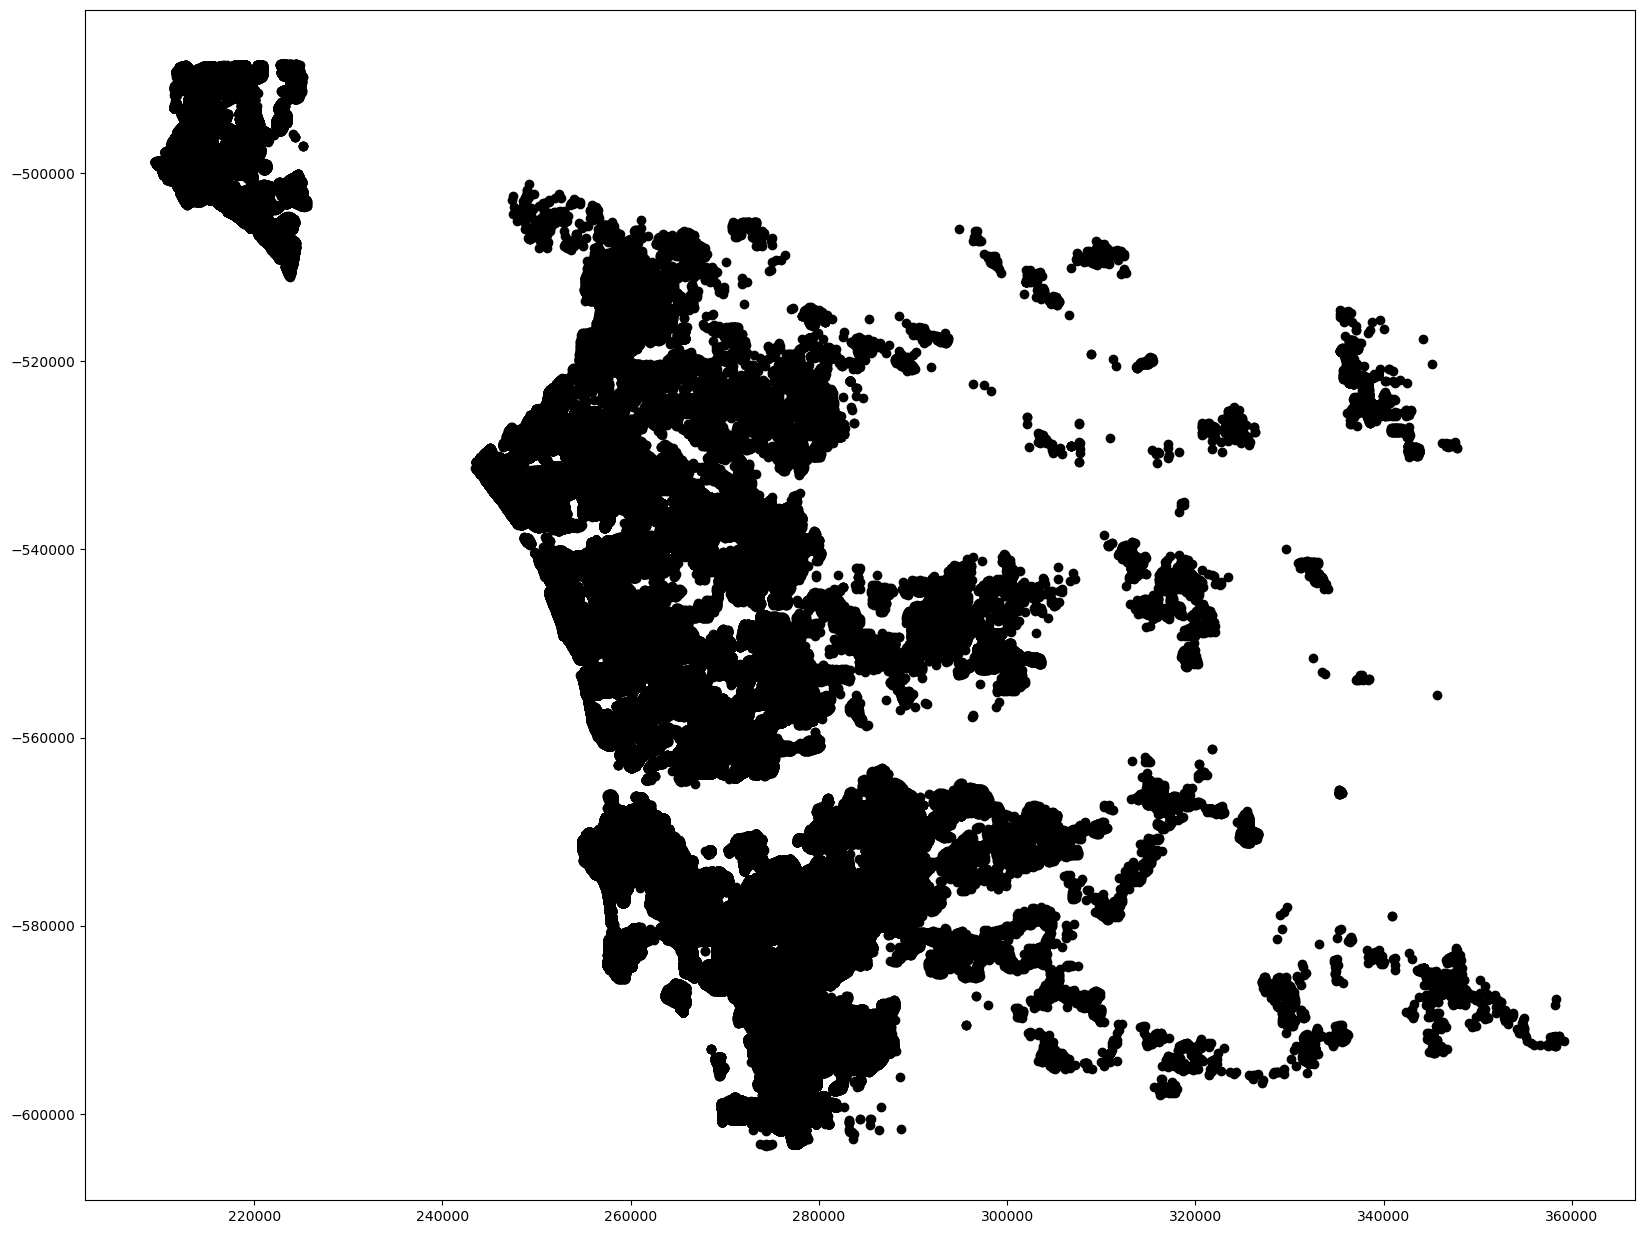

In [67]:
# plot all of the data sources to ensure everything looks accurate 
fig, ax = plt.subplots(figsize=(20, 20))

# ax.axis('off')

sdge_singlefamily_linked.plot(ax=ax, 
                    color='black')

sdge_multifamily_linked.plot(ax=ax, 
                    color='#F6BE9A')

sdge_feederlines.plot(ax=ax, 
                      color='#004643')

census_tracts.boundary.plot(ax=ax, 
                    color='red')

In [ ]:
# verify all of the data frames have the same crs 
assert census_tracts.crs == sdge_feederlines.crs
assert census_tracts.crs == sdge_multifamily_linked.crs
assert census_tracts.crs == sdge_singlefamily_linked.crs

# filter census tract to just one census tract
example_census = census_tracts[census_tracts['TRACTCE'] == '004200']

# clip all of the other data to the one census tract
example_feeder = sdge_feederlines.clip(example_census)
example_multifamily = sdge_multifamily_linked.clip(example_census)
example_singlefamily = sdge_singlefamily_linked.clip(example_census)


Let's make sure this is a good census tract to conduct a hosting capacity analysis on. Let's count the number of homes in this census tract.

In [ ]:
print(f"The selected census tract has",len(example_singlefamily), " single family homes.")

The selected census tract has 2893  single family homes.


Text(0.5, 1.0, 'Example census tract')

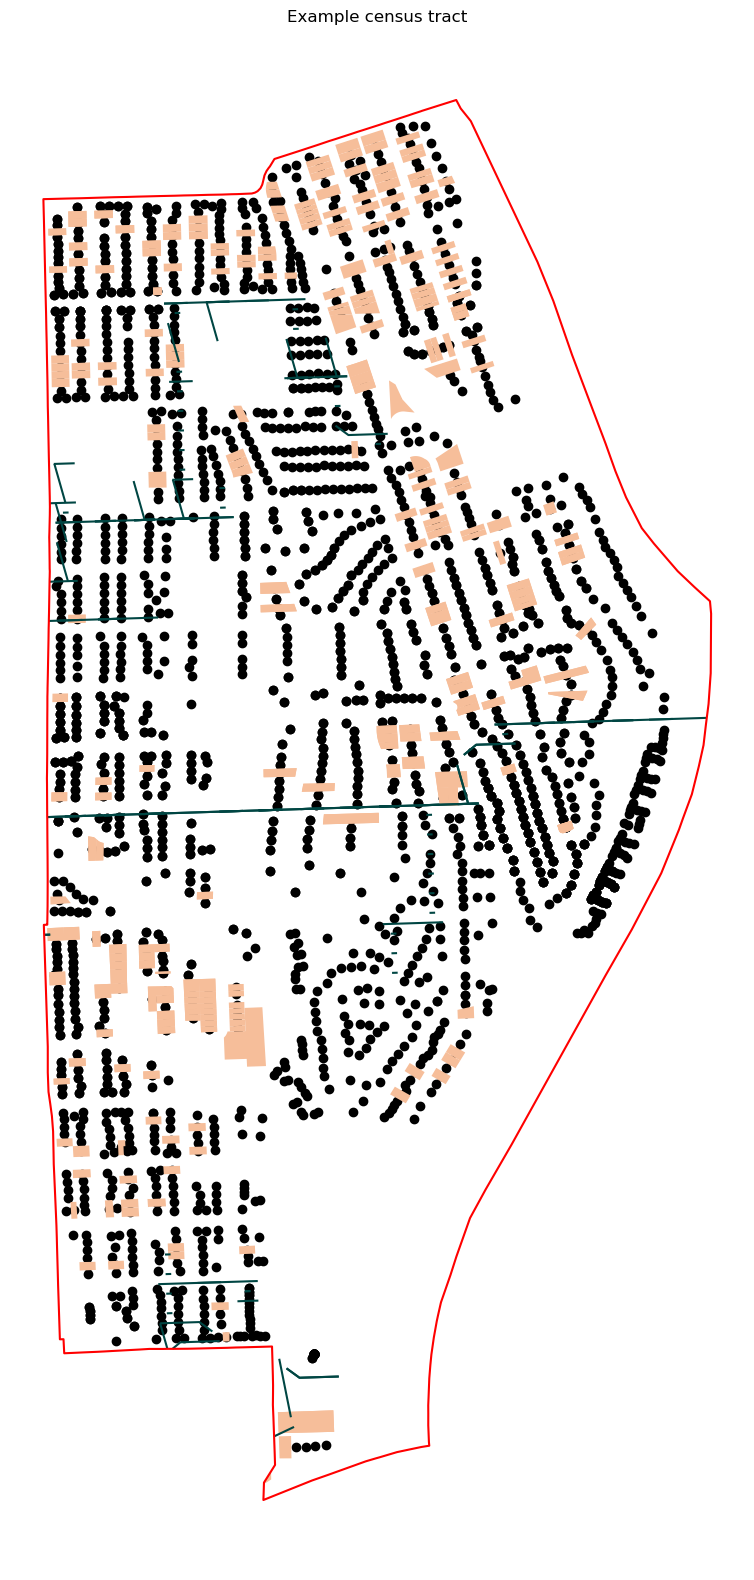

In [ ]:
# plot all of the data sources to ensure just one census tract is present 
fig, ax = plt.subplots(figsize=(20, 20))

ax.axis('off')

example_singlefamily.plot(ax=ax, 
                    color='black')

example_multifamily.plot(ax=ax, 
                    color='#F6BE9A')

example_feeder.plot(ax=ax, 
                      color='#004643')

example_census.boundary.plot(ax=ax, 
                    color='red')

plt.title('Example census tract')

#### 1. View the maximum hosting capactiy
For this example let's look at the ICA with no operational flex uniform generation.

In [ ]:
# view the max ICA no operational flex 
print(example_singlefamily['ICAWNOF_UNIGENERATION'].max())
print(example_multifamily['ICAWNOF_UNIGENERATION'].max())
print(example_feeder['ICAWNOF_UNIGENERATION'].max())

5.7
5.7
5.7


The maximum ICA with no operational flex uniform generation are the same across the feederlines, the single family homes, and the multi-family homes. This is expected since the feederlines are connected to all of the residential buildings. 

In [ ]:
# view the minimum ICA with no operational flex generation capacity 
print(example_singlefamily['ICAWNOF_UNIGENERATION'].min())
print(example_multifamily['ICAWNOF_UNIGENERATION'].min())
print(example_feeder['ICAWNOF_UNIGENERATION'].min())

0.1
0.1
0.1
